# Comparison experiments


In [27]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from jax import jit, vmap
from jax import jacfwd, jacrev
from jax.scipy.stats import multivariate_normal
from functions import F_P, GradientKernel,KernelGradientDiscrepancy
import jax_kernels as ker
from mfld import MeanFieldLangevinDynamics
from generalized_svgd import GeneralizedSVGD
from extensible_sampling import ExtensibleSampling
from variational_inference import VariationalInference
import functions as f

import jax
from jax import random

# 1. $\mathcal{L}$ is linear.

- $q_0(x) \propto \exp(-\|x\|^2/2)$
- $\mathcal{L}(Q)(x) = \int v(x) \ d Q(x)$, with $v(x) =  \frac{-\|x\|^2}{4}$


In this case, $\mathcal{L}'(Q)(x) = v(x)$ and $p(x) \propto e^{-\frac{\|x\|^2}{4}}$, so $P = \mathcal{N}(0,2 I_d)$.

KGD kernel :  IMQ   : $k(x,y) = \frac{1}{\sqrt{c + \|x-y\|^2}}$. 


<!-- F(q) = L(q) + Kl(q|q0) = L(q) + int -log q0 dq +int log q dq 
L(Q) = int v(x)dq
alors F(q) = int v(x)-log q0 dQ + int log q dq = KL(q|p) où p(x) propto q0 exp(v) = exp(-||x||^2/2 + v)


P(x) propto qO(x) exp(-L'(P)(x)) -->


In [2]:
results = {
    "MFLD": {
        "X_fin": None,
        "KGD": None
    },
    "Generalized SVGD": {
        "X_fin": None,
        "KGD_values": None
    },
    "ES": {
        "X_fin": None,
        "KGD_values": None
    },
    "VI": {
        "X_fin": None,
        "KGD_values": None
    }
}

In [ ]:
#Upload results
import pickle

# Chargement depuis le fichier
with open("results.pkl", "rb") as f:
    results = pickle.load(f)

In [30]:
c = 1
def k(x,y):
    return 1/jnp.sqrt((c + jnp.dot(x-y,x-y)))

def q_0(x):
    return jnp.exp(-jnp.linalg.norm(x)**2/2) #/ jnp.sqrt((2 *jnp.pi)**d)

def v(X):
    return -1/4 * jnp.linalg.norm(X, axis=1)**2 

def L(X):
    return jnp.mean(v(X))

k = jit(k)
q_0 = jit(q_0)
v = jit(v)
L = jit(L)

In [31]:
MFLD = MeanFieldLangevinDynamics(q_0,L,k)
d=2
VI = VariationalInference(q_0,L,k,d)
F_P = f.F_P(q_0, L)
k_pq = f.GradientKernel(VI.S_PQ,k)
KGD = f.KernelGradientDiscrepancy(k_pq)

# Mean Field Langevin Dynamics

In [32]:
MFLD = MeanFieldLangevinDynamics(q_0,L,k)

T = 1000
n = 100
d = 2
eta = 0.1 # the best stepsize 

key_init = random.PRNGKey(100)
key = random.PRNGKey(200)
X0 = random.normal(key_init, (n,d)) + 5 * jnp.ones((n, d))

all_particles = MFLD.run_particles(eta, T, X0,key)
results["MFLD"]["X_fin"] = all_particles[-1]

KGD_values = jnp.zeros(T)
for it in range(T):
    KGD_values = KGD_values.at[it].set(KGD.evaluate(all_particles[it]))

results["MFLD"]["KGD"] = KGD_values


# Generalized SVGD

In [33]:
sigma_m = 5.0
m = lambda x,y : ker.k_gauss(x, y, sigma=sigma_m)
dm = lambda x,y : ker.dk_gauss(x, y, sigma=sigma_m)

G_SVGD = GeneralizedSVGD(q_0,L,k,m,dm)

T = 1000
n = 100
d = 2
eta = 2.0 # the best stepsize 

key_init = random.PRNGKey(100)
key = random.PRNGKey(200)
X0 = random.normal(key_init, (n,d)) + 5 * jnp.ones((n, d))

all_particles = G_SVGD.run_particles(eta, T, X0)
results["Generalized SVGD"]["X_fin"] = all_particles[-1]

KGD_values = jnp.zeros(T)
for it in range(T):
    KGD_values = KGD_values.at[it].set(KGD.evaluate(all_particles[it]))

results["Generalized SVGD"]["KGD"] = KGD_values


# Extansible sampling 

In [7]:
ES = ExtensibleSampling(q_0,L,k)

T = 100
d = 2

key = random.PRNGKey(200)
x0 = random.normal(key, (d,)) 
X_fin = ES.run_particles(x0,T)

results["ES"]["X_fin"] = X_fin

KGD_values = jnp.zeros(T)
for it in range(T):
    KGD_values = KGD_values.at[it].set(KGD.evaluate(X_fin[:it+1]))

results["ES"]["KGD"] = KGD_values


Iteration: 10
Iteration: 20
Iteration: 30
Iteration: 40
Iteration: 50
Iteration: 60
Iteration: 70
Iteration: 80
Iteration: 90


# Variational Inference

In [49]:
eta = 0.1
T = 1000
d = 2

VI = VariationalInference(q_0,L,k,d)

key = random.PRNGKey(1)
Theta = VI.run(key,eta,T)
theta_fin = Theta[-1]

W_fin = random.normal(random.PRNGKey(2), (100, d))
X_fin = VI.model(theta_fin, W_fin)
results["VI"]["X_fin"] = X_fin

Save data:

In [51]:
import pickle

# Sauvegarde dans un fichier binaire
with open("results.pkl", "wb") as f:
    pickle.dump(results, f)

# Comparison of the experiments

Here we plot the final particles position obtained for each of the method. 

In [52]:
#Upload results
import pickle

# Chargement depuis le fichier
with open("results.pkl", "rb") as f:
    results_loaded = pickle.load(f)


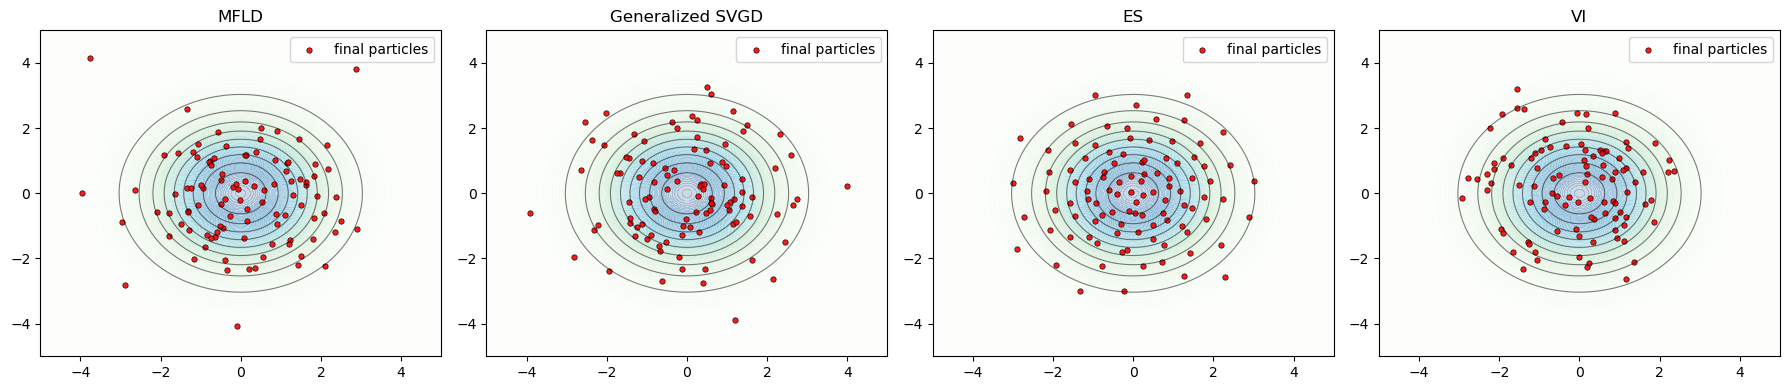

In [53]:
mean = jnp.zeros(2)  
cov = jnp.eye(2) * 2.0  

x = jnp.linspace(-5, 5, 100)
y = jnp.linspace(-5, 5, 100)
X, Y = jnp.meshgrid(x, y)
pos = jnp.dstack((X, Y))

Z = multivariate_normal.pdf(pos, mean, cov)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ind, expe in enumerate(results.keys()):
    
    # Fond dégradé avec transparence
    cf = axes[ind].contourf(
        X, Y, Z, 
        levels=100,          # plus de niveaux pour un dégradé lisse
        cmap='GnBu', 
        alpha=0.2     # transparence du fond
    )
    
    # Lignes de contour par-dessus
    axes[ind].contour(
        X, Y, Z, 
        levels=10, 
        colors='black', 
        linewidths=0.8,
        alpha=0.5
    )
    
    # Points très contrastés
    axes[ind].scatter(
        results_loaded[expe]["X_fin"][:, 0],
        results_loaded[expe]["X_fin"][:, 1],
        label="final particles",
        c='red',
        edgecolor='black',
        linewidth=0.5,
        s=15,
        alpha=0.9
    )
    
    axes[ind].set_xlim(-5, 5)
    axes[ind].set_ylim(-5, 5)
    axes[ind].set_title(expe)
    axes[ind].legend()

plt.tight_layout()
plt.show()